In [2]:
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

In [3]:
# dataset
df = pd.read_csv(r'data/knn/breast+cancer+wisconsin+diagnostic/wdbc.data', header=None)

# since no column names
columns = [
    "id",
    "diagnosis",

    "radius_mean",
    "texture_mean",
    "perimeter_mean",
    "area_mean",
    "smoothness_mean",
    "compactness_mean",
    "concavity_mean",
    "concave_points_mean",
    "symmetry_mean",
    "fractal_dimension_mean",

    "radius_se",
    "texture_se",
    "perimeter_se",
    "area_se",
    "smoothness_se",
    "compactness_se",
    "concavity_se",
    "concave_points_se",
    "symmetry_se",
    "fractal_dimension_se",

    "radius_worst",
    "texture_worst",
    "perimeter_worst",
    "area_worst",
    "smoothness_worst",
    "compactness_worst",
    "concavity_worst",
    "concave_points_worst",
    "symmetry_worst",
    "fractal_dimension_worst"
]

df.columns = columns

# we set to go from here
df.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave_points_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave_points_worst,symmetry_worst,fractal_dimension_worst
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [4]:
# X and y definition
y = df['diagnosis']
X = df.drop(columns = ['id', 'diagnosis'])

X.shape, y.shape

((569, 30), (569,))

In [5]:
X.head()

,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave_points_mean,symmetry_mean,fractal_dimension_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave_points_worst,symmetry_worst,fractal_dimension_worst
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [6]:
y.head()

0    M
1    M
2    M
3    M
4    M
Name: diagnosis, dtype: str

In [7]:
y = y.map({"M":1, "B":0})
y.head()

0    1
1    1
2    1
3    1
4    1
Name: diagnosis, dtype: int64

In [8]:
y.value_counts()

diagnosis
0    357
1    212
Name: count, dtype: int64

In [9]:
# all set, now torching it
X = torch.tensor(X.values, dtype = torch.float32)
y = torch.tensor(y.values, dtype = torch.long)

print(f'Shape    : X is {X.shape}, y is {y.shape}\nData Type: X is {X.dtype},         y is {y.dtype}')

Shape    : X is torch.Size([569, 30]), y is torch.Size([569])
Data Type: X is torch.float32,         y is torch.int64


In [10]:
# spliting twice for getting TRAINING, VALIDATION, TESTING dataset
X_train_val, X_test, y_train_val, y_test = train_test_split(X, y, test_size = 0.20, random_state=42)

X_train, X_val, y_train, y_val = train_test_split(X_train_val, y_train_val, test_size = 0.25, random_state=42)

print(f'TRAINING:   {X_train.shape}\nVALIDATION: {X_val.shape}\nTESTING:    {X_test.shape}')

TRAINING:   torch.Size([341, 30])
VALIDATION: torch.Size([114, 30])
TESTING:    torch.Size([114, 30])


In [11]:
# normalizing data
mean = X_train.mean(dim=0)
std = X_train.std(dim=0)
X_train = (X_train - mean)/std
X_test = (X_test - mean)/std
X_val = (X_val - mean)/std

In [12]:
# defining the distance formula
def euclid(x,y):
    return torch.sqrt(torch.sum((x-y)**2))

In [13]:
# creating the class
class KNN:
    def __init__(self, k=5):
        self.k = k

    def fit(self, X, y):
        self.X_train = X
        self.y_train = y

    def predict(self, x):
        preds = []
        for i in x:
            dist = []
            for xx in self.X_train:
                dist.append(euclid(i, xx))
            dist = torch.tensor(dist)
            k_ind = torch.argsort(dist)[:self.k]
            k_labels = self.y_train[k_ind]
            pred = torch.bincount(k_labels).argmax()
            preds.append(pred)
        return preds

In [14]:
knn = KNN(5)
knn.fit(X_train, y_train)

In [15]:
y_pred = knn.predict(X_test)

In [16]:
print(y_pred[:20])

[tensor(0), tensor(1), tensor(1), tensor(0), tensor(0), tensor(1), tensor(1), tensor(1), tensor(1), tensor(0), tensor(0), tensor(1), tensor(0), tensor(0), tensor(0), tensor(1), tensor(0), tensor(0), tensor(0), tensor(1)]


In [17]:
y_pred = torch.tensor(y_pred, dtype=torch.long)

In [18]:
def accuracy(y_true, y_pred):
    return (y_true == y_pred).float().mean()

In [19]:
acc = accuracy(y_test, y_pred)
print(f"Accuracy: {acc:.4f}")

Accuracy: 0.9474


In [20]:
k_values = [1, 3, 5, 7, 9, 11, 15, 21]

results = []

for k in k_values:
    knn = KNN(k=k)
    knn.fit(X_train, y_train)

    y_val_pred = torch.tensor(knn.predict(X_val),dtype=torch.long)

    acc = accuracy(y_val, y_val_pred)
    results.append(acc.item())

    print(f"K = {k:2d} | Validation Accuracy = {acc:.4f}")

K =  1 | Validation Accuracy = 0.9649
K =  3 | Validation Accuracy = 0.9825
K =  5 | Validation Accuracy = 0.9825
K =  7 | Validation Accuracy = 0.9737
K =  9 | Validation Accuracy = 0.9561
K = 11 | Validation Accuracy = 0.9561
K = 15 | Validation Accuracy = 0.9649
K = 21 | Validation Accuracy = 0.9561


In [21]:
best_k = k_values[results.index(max(results))]
print(best_k)

3


In [22]:
knn = KNN(k=best_k)
knn.fit(X_train, y_train)

y_pred = torch.tensor(knn.predict(X_test), dtype=torch.long)

In [23]:
# eval metrics
def confusion_matrix(y_true, y_pred):
    cm = torch.zeros((2, 2), dtype=torch.int64)
    for true, pred in zip(y_true, y_pred):
        cm[true, pred] += 1
    return cm

def precision(cm):
    TP = cm[1, 1]
    FP = cm[0, 1]
    return TP / (TP + FP)

def recall(cm):
    TP = cm[1, 1]
    FN = cm[1, 0]
    return TP / (TP + FN)

def f1_score(precision, recall):
    return 2 * precision * recall / (precision + recall)

In [24]:
cm = confusion_matrix(y_test, y_pred)
p = precision(cm)
r = recall(cm)
f1 = f1_score(p, r)

print(f"Confusion Matrix: {cm}")

print(f"Precision: {p:.4f}")
print(f"Recall:    {r:.4f}")
print(f"F1 Score:  {f1:.4f}")

Confusion Matrix: tensor([[68,  3],
        [ 3, 40]])
Precision: 0.9302
Recall:    0.9302
F1 Score:  0.9302


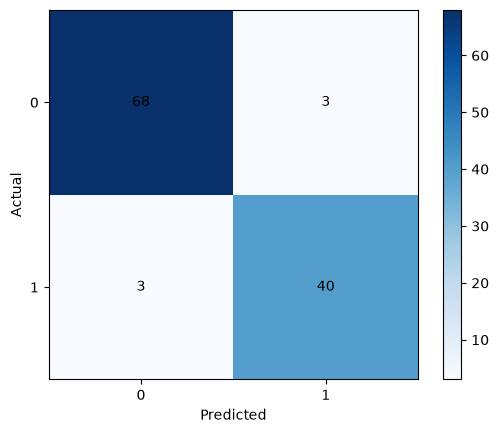

In [25]:
plt.imshow(cm, cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.xticks([0, 1])
plt.yticks([0, 1])
plt.colorbar()

for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i, j].item(), ha="center", va="center")
plt.show()